# Acidification Profiles in Cheese Making

**Contact:** Dimitri Bocquel  
**Authors:** Lilandra Albert-Lavault & Samuele Moungang  
**Data collected:** 05 mai 2026

| Source | File | Résolution | Canaux |
|--------|------|------------|--------|
| Fromage 1 — USB | `00000005.CSV` | 1 min | pH, mV |
| Fromage 2 — Server | `trace_pH_fromage_2_Server_05052026.csv` | ~1 s | pH |
| Fromage 3 — Hannah (PHLOT002) | `trace_pH_fromage_3_05052026_hannah.CSV` | 1 min | pH, mV, T°C |

---

## Pipeline
1. **Load & inspect** raw data
2. **Interpolation** — combler les lacunes du signal server (grille 1 s régulière)
3. **Resampling** — grille 1 min commune
4. **Correction Nernst** — corriger le pH mesuré en fonction de la température réelle de l'électrode
5. **Fit logistique** — ajustement d'un modèle de déclin logistique
6. **Modèle Luedeking-Piret** — décomposition de la cinétique d'acidification

---
## 0. Setup

In [1]:
import sys
import os
# Décommentez si scipy est absent :
# !{sys.executable} -m pip install scipy --quiet

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from scipy.signal import savgol_filter
from scipy.interpolate import interp1d
from scipy.optimize import curve_fit

plt.rcParams.update({
    'figure.figsize': (14, 4.5),
    'figure.dpi': 120,
    'font.size': 11,
    'axes.grid': True,
    'grid.alpha': 0.3,
})

# Créez un dossier pour les figures si nécessaire
FIGURES_DIR = 'figures_05052026'
os.makedirs(FIGURES_DIR, exist_ok=True)

# Constantes physiques — équation de Nernst
R    = 8.314      # J mol⁻¹ K⁻¹
F    = 96485.0    # C mol⁻¹
LN10 = np.log(10)

def nernst_slope(T_celsius):
    """Pente de Nernst théorique en mV/pH à la température T (°C)."""
    return -(R * (T_celsius + 273.15) * LN10 / F) * 1000

T_CAL = 25.0   # Température de calibration de référence supposée (USB & Server)
print(f'Pente Nernst @ {T_CAL}°C : {nernst_slope(T_CAL):.3f} mV/pH')
print(f'Pente Nernst @ 37°C    : {nernst_slope(37):.3f} mV/pH')

Pente Nernst @ 25.0°C : -59.156 mV/pH
Pente Nernst @ 37°C    : -61.537 mV/pH


---
## 1. Chargement & Inspection des Données Brutes

In [2]:
# ── Fromage 1 — USB (pH + mV, 1 min) — 05/05/2026 ──────────────────────────
df1_raw = pd.read_csv(
    'data_5_mai/00000005.CSV',
    usecols=['Date', 'Time', 'Ch1_M1', 'Ch1_M3'],
)
df1_raw['datetime'] = pd.to_datetime(
    df1_raw['Date'] + ' ' + df1_raw['Time'], format='%d/%b/%Y %H:%M:%S'
)
df1_raw['pH'] = pd.to_numeric(df1_raw['Ch1_M1'], errors='coerce')
df1_raw['mV'] = pd.to_numeric(df1_raw['Ch1_M3'], errors='coerce')
df1_all = df1_raw[['datetime', 'pH', 'mV']].dropna().set_index('datetime').sort_index()

# Filtre 1 : journée du 05 mai uniquement (la clé enregistre en continu sur plusieurs jours)
df1_all = df1_all[df1_all.index.date == pd.Timestamp('2026-05-05').date()]

# Filtre 2 : supprimer les artefacts (sonde hors du lait, calibrations)
# pH < 3.5 ou > 7.0 = sonde à l'air ou en solution de rinçage
df1_all = df1_all[(df1_all['pH'] >= 3.5) & (df1_all['pH'] <= 7.0)].copy()

# Filtre 3 : fenêtre fermentation active — la sonde quitte le lait vers 15:20
# (valeurs qui chutent à ~3.95 = sonde dans solution acide / à l'air)
df1 = df1_all[
    (df1_all.index >= pd.Timestamp('2026-05-05 10:00:00')) &
    (df1_all.index <= pd.Timestamp('2026-05-05 15:20:00'))
].copy()

print(f'Fromage 1 (USB)    : {len(df1):,} points | {df1.index[0]} → {df1.index[-1]}')
print(f'  Artefacts éliminés : {len(df1_raw) - len(df1_all):,} points (pH < 3.5 ou > 7.0)')
print(f'  pH initial : {df1["pH"].iloc[0]:.2f} | pH final : {df1["pH"].iloc[-1]:.2f}')
df1.describe()

Fromage 1 (USB)    : 312 points | 2026-05-05 10:08:52 → 2026-05-05 15:19:52
  Artefacts éliminés : 953 points (pH < 3.5 ou > 7.0)
  pH initial : 5.30 | pH final : 5.22


,pH,mV
count,312.000000,312.000000
mean,5.602276,82.945513
std,0.333557,19.575238
min,5.220000,10.000000
25%,5.330000,67.000000
50%,5.480000,90.000000
75%,5.870000,99.000000
max,6.840000,105.000000


In [3]:
# ── Fromage 2 — Server (pH uniquement, ~1 s) — 05/05/2026 ───────────────────
df2_raw = pd.read_csv(
    'data_5_mai/trace_pH_fromage_2_Server_05052026.csv',
    names=['datetime', 'pH'], skiprows=1,
)
df2_raw['datetime'] = pd.to_datetime(df2_raw['datetime'])
df2_raw['pH'] = pd.to_numeric(df2_raw['pH'], errors='coerce')
df2_raw = df2_raw.dropna().set_index('datetime').sort_index()

# Supprimer les artefacts
df2_clean = df2_raw[(df2_raw['pH'] >= 3.5) & (df2_raw['pH'] <= 7.0)].copy()

# Supprimer la période avant 11:00 (sonde hors mesure réelle)
df2_clean = df2_clean[df2_clean.index >= pd.Timestamp('2026-05-05 11:00:00')]

# Rééchantillonnage à 1 min (médiane)
df2 = df2_clean['pH'].resample('1min').median().dropna().to_frame()

print(f'Fromage 2 (Server) : {len(df2_raw):,} pts bruts | artefacts éliminés : {len(df2_raw) - len(df2_clean):,}')
print(f'  Après filtre + rééchantillonnage 1 min : {len(df2):,} points | {df2.index[0]} → {df2.index[-1]}')
df2.describe()

Fromage 2 (Server) : 1,721 pts bruts | artefacts éliminés : 825
  Après filtre + rééchantillonnage 1 min : 247 points | 2026-05-05 11:00:00 → 2026-05-05 15:18:00


,pH
count,247.000000
mean,5.216856
std,0.382020
min,4.506494
25%,4.887268
50%,5.174614
75%,5.508446
max,6.239230


In [4]:
# ── Fromage 3 — Hannah PHLOT002 (pH + mV + T°C, 1 min) — 05/05/2026 ─────────
# Le fichier utilise ';' comme séparateur et ',' comme décimale (format européen)
df3_raw = pd.read_csv(
    'data_5_mai/trace_pH_fromage_3_05052026_hannah.CSV',
    skiprows=20, header=None, sep=';',
    names=['_', 'rec', 'date', 'time', 'pH', 'u1', 'mV', 'u2', 'temp_C', 'u3', '_2'],
    usecols=['date', 'time', 'pH', 'mV', 'temp_C'],
    encoding='latin-1',
)
df3_raw['datetime'] = pd.to_datetime(
    df3_raw['date'].str.strip() + ' ' + df3_raw['time'].str.strip(),
    format='%Y-%m-%d %H:%M:%S'
)
for col in ['pH', 'mV', 'temp_C']:
    df3_raw[col] = pd.to_numeric(
        df3_raw[col].astype(str).str.replace(',', '.', regex=False), errors='coerce'
    )
df3_all = df3_raw[['datetime', 'pH', 'mV', 'temp_C']].dropna().set_index('datetime').sort_index()
df3 = df3_all[(df3_all['pH'] >= 3.5) & (df3_all['pH'] <= 7.0)].copy()

print(f'Fromage 3 (Hannah PHLOT002) : {len(df3):,} points | {df3.index[0]} → {df3.index[-1]}')
print(f'  pH final (dernière valeur) : {df3["pH"].iloc[-1]:.2f}  '
      '⚠️ Fermentation probablement incomplète (pH > 5.15 attendu)')
df3.describe()

Fromage 3 (Hannah PHLOT002) : 286 points | 2026-05-05 11:23:27 → 2026-05-05 16:08:28
  pH final (dernière valeur) : 5.15  ⚠️ Fermentation probablement incomplète (pH > 5.15 attendu)


,pH,mV,temp_C
count,286.000000,286.000000,286.000000
mean,5.620000,86.717832,34.725874
std,0.362212,21.296485,2.266684
min,5.150000,39.300000,25.700000
25%,5.270000,66.775000,34.000000
50%,5.485000,94.750000,34.300000
75%,5.960000,107.075000,35.300000
max,6.420000,114.400000,40.100000


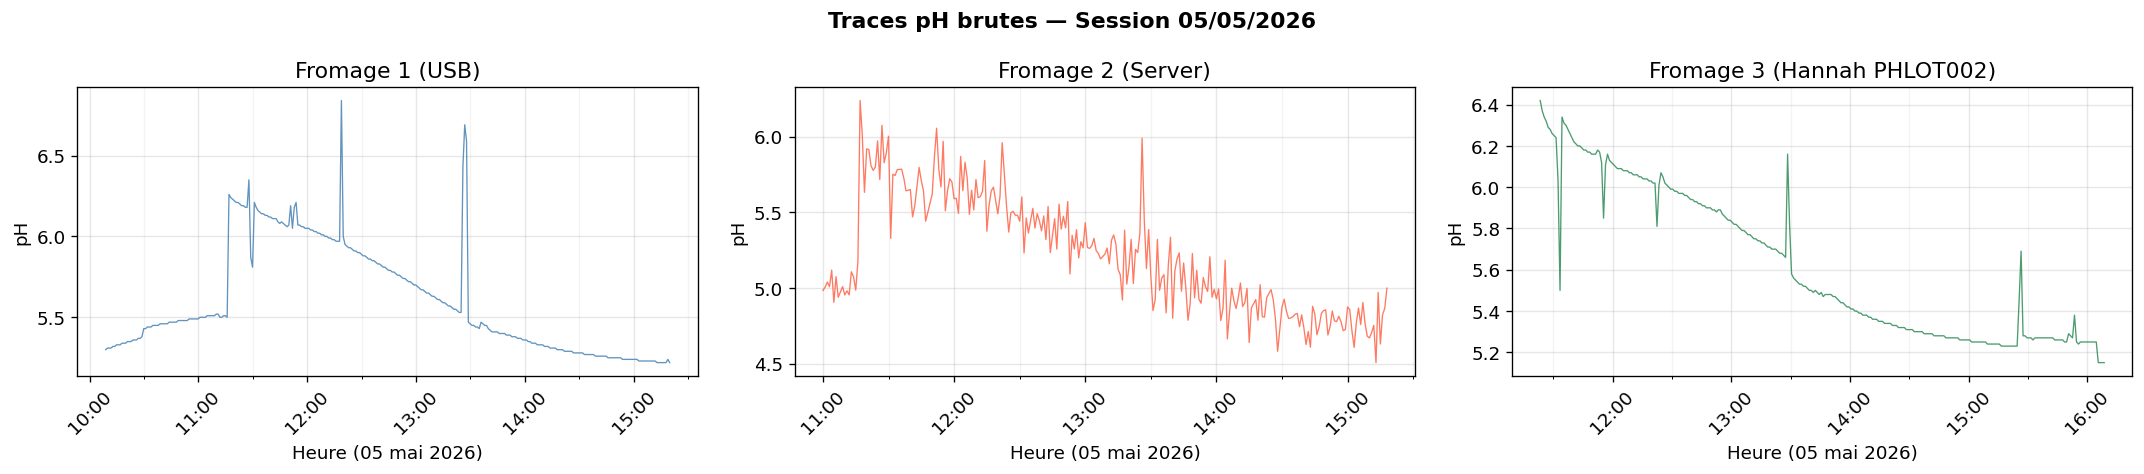

In [5]:
# Vue d'ensemble brute — 3 panneaux
fig, axes = plt.subplots(1, 3, figsize=(18, 4))

for ax, df, label, color in zip(
    axes,
    [df1, df2, df3],
    ['Fromage 1 (USB)', 'Fromage 2 (Server)', 'Fromage 3 (Hannah PHLOT002)'],
    ['steelblue', 'tomato', 'seagreen'],
):
    duration_h = (df.index[-1] - df.index[0]).total_seconds() / 3600
    major_interval = 2 if duration_h > 8 else 1

    ax.plot(df.index, df['pH'], color=color, linewidth=0.8, alpha=0.85)
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))
    ax.xaxis.set_major_locator(mdates.HourLocator(interval=major_interval))
    ax.xaxis.set_minor_locator(mdates.MinuteLocator(byminute=[30]))
    ax.grid(True, which='minor', alpha=0.15)
    plt.setp(ax.xaxis.get_majorticklabels(), rotation=45)
    ax.set_title(label)
    ax.set_ylabel('pH')
    ax.set_xlabel('Heure (05 mai 2026)')

plt.suptitle('Traces pH brutes — Session 05/05/2026', fontweight='bold')
plt.tight_layout()
plt.savefig(f'{FIGURES_DIR}/01_raw_traces.png', bbox_inches='tight')
plt.show()

---
## 2. Interpolation — Combler les Lacunes du Signal Server (Fromage 2)

Le logger Server enregistre à ~1 s mais présente des lacunes. On interpole linéairement sur une grille 1 min régulière, en signalant les segments non fiables.

In [6]:
# ── Détection des lacunes ─────────────────────────────────────────────────────
GAP_THRESHOLD_S = 120   # > 2 min = lacune réelle sur grille 1 min
dt_seconds = df2.index.to_series().diff().dt.total_seconds()
gaps = dt_seconds[dt_seconds > GAP_THRESHOLD_S].dropna()
print(f'Lacunes > {GAP_THRESHOLD_S} s dans Fromage 2 : {len(gaps)}')
if len(gaps):
    print(gaps.apply(lambda s: f'{s:.0f} s').to_frame('durée_lacune'))

# ── Grille régulière 1 min ────────────────────────────────────────────────────
t_start     = df2.index[0]
t_end       = df2.index[-1]
regular_idx = pd.date_range(t_start, t_end, freq='1min')

t_orig = (df2.index - t_start).total_seconds().values
t_new  = (regular_idx - t_start).total_seconds().values

interp_fn = interp1d(t_orig, df2['pH'].values, kind='linear',
                     bounds_error=False, fill_value=np.nan)
pH_interp = interp_fn(t_new)

# ── Masquer les segments interpolés dans les grandes lacunes ──────────────────
reliable = np.ones(len(regular_idx), dtype=bool)
for gap_ts, gap_dur in gaps.items():
    prev_ts = gap_ts - pd.Timedelta(seconds=gap_dur)
    mask = (regular_idx > prev_ts) & (regular_idx < gap_ts)
    reliable[mask] = False

df2_interp = pd.DataFrame({'pH': pH_interp, 'reliable': reliable}, index=regular_idx)
print(f'\nGrille régulière : {len(df2_interp):,} pts | fiables : {reliable.sum():,}')

Lacunes > 120 s dans Fromage 2 : 1
                    durée_lacune
datetime                        
2026-05-05 11:50:00        180 s

Grille régulière : 259 pts | fiables : 257


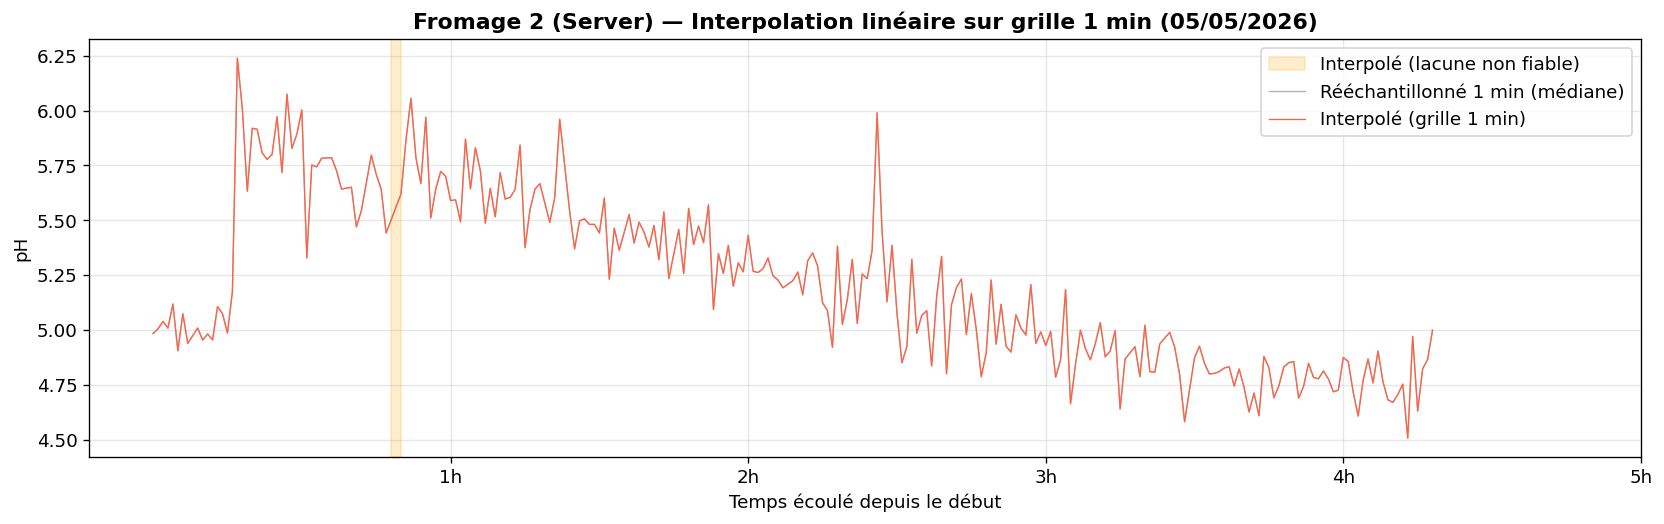

In [7]:
fig, ax = plt.subplots(figsize=(14, 4.5))

t0 = df2_interp.index[0]

def to_hours(idx):
    return (idx - t0).total_seconds() / 3600

# Zones d'interpolation non fiables
in_gap, gap_start = False, None
for ts, row in df2_interp.iterrows():
    if not row['reliable'] and not in_gap:
        gap_start, in_gap = ts, True
    elif row['reliable'] and in_gap:
        ax.axvspan(to_hours(gap_start), to_hours(ts), alpha=0.2, color='orange',
                   label='Interpolé (lacune non fiable)')
        in_gap = False
if in_gap:
    ax.axvspan(to_hours(gap_start), to_hours(df2_interp.index[-1]), alpha=0.2, color='orange')

ax.plot(to_hours(df2.index), df2['pH'],
        color='grey', linewidth=0.8, alpha=0.6, label='Rééchantillonné 1 min (médiane)')
ax.plot(to_hours(df2_interp.index), df2_interp['pH'],
        color='tomato', linewidth=0.8, label='Interpolé (grille 1 min)')

x_max = to_hours(df2_interp.index[-1])
ticks = np.arange(1, int(np.ceil(x_max)) + 1)
ax.set_xticks(ticks)
ax.set_xticklabels([f'{int(t)}h' for t in ticks])

ax.set_title('Fromage 2 (Server) — Interpolation linéaire sur grille 1 min (05/05/2026)', fontweight='bold')
ax.set_xlabel('Temps écoulé depuis le début')
ax.set_ylabel('pH')
handles, labels = ax.get_legend_handles_labels()
ax.legend(dict(zip(labels, handles)).values(), dict(zip(labels, handles)).keys())
plt.tight_layout()
plt.savefig(f'{FIGURES_DIR}/02_interpolation.png', bbox_inches='tight')
plt.show()

---
## 3. Rééchantillonnage

Les trois signaux sont rééchantillonnés à la **médiane sur 1 minute** pour obtenir une grille commune.  
Le signal Server (~1 s) présente un bruit résiduel important non supprimé par la seule médiane 1 min.  
Un **filtre de Savitzky-Golay** (fenêtre 21 min, degré 3) est appliqué uniquement au Server pour lisser sans déformer la tendance ni introduire de décalage temporel.

In [8]:
RESAMPLE_FREQ = '1min'
SG_WINDOW     = 21   # Savitzky-Golay window for Server (minutes, must be odd)

def resample_data(series, freq=RESAMPLE_FREQ):
    return series.resample(freq).median().dropna()

df1_res = df1_smooth = resample_data(df1['pH'])
df3_res = df3_smooth = resample_data(df3['pH'])

# Server (Fromage 2) : médiane 1 min puis Savitzky-Golay
df2_res  = resample_data(df2_interp['pH'])
_sg_vals = savgol_filter(df2_res.values, window_length=SG_WINDOW, polyorder=3)
df2_smooth = pd.Series(_sg_vals, index=df2_res.index, name='pH')

df1_mV_res   = df1['mV'].resample(RESAMPLE_FREQ).median().dropna()
df3_mV_res   = df3['mV'].resample(RESAMPLE_FREQ).median().dropna()
df3_temp_res = df3['temp_C'].resample(RESAMPLE_FREQ).median().dropna()

print('Tailles après rééchantillonnage :')
for name, s in [('Fromage 1 (USB)',         df1_res),
                ('Fromage 2 (Server brut)',  df2_res),
                ('Fromage 2 (Server SG)',    df2_smooth),
                ('Fromage 3 (Hannah)',       df3_res)]:
    print(f'  {name} : {len(s):,} points | {s.index[0]} → {s.index[-1]}')
print(f'\nServer : Savitzky-Golay fenêtre={SG_WINDOW} min, degré=3')

Tailles après rééchantillonnage :
  Fromage 1 (USB) : 312 points | 2026-05-05 10:08:00 → 2026-05-05 15:19:00
  Fromage 2 (Server brut) : 259 points | 2026-05-05 11:00:00 → 2026-05-05 15:18:00
  Fromage 2 (Server SG) : 259 points | 2026-05-05 11:00:00 → 2026-05-05 15:18:00
  Fromage 3 (Hannah) : 286 points | 2026-05-05 11:23:00 → 2026-05-05 16:08:00

Server : Savitzky-Golay fenêtre=21 min, degré=3


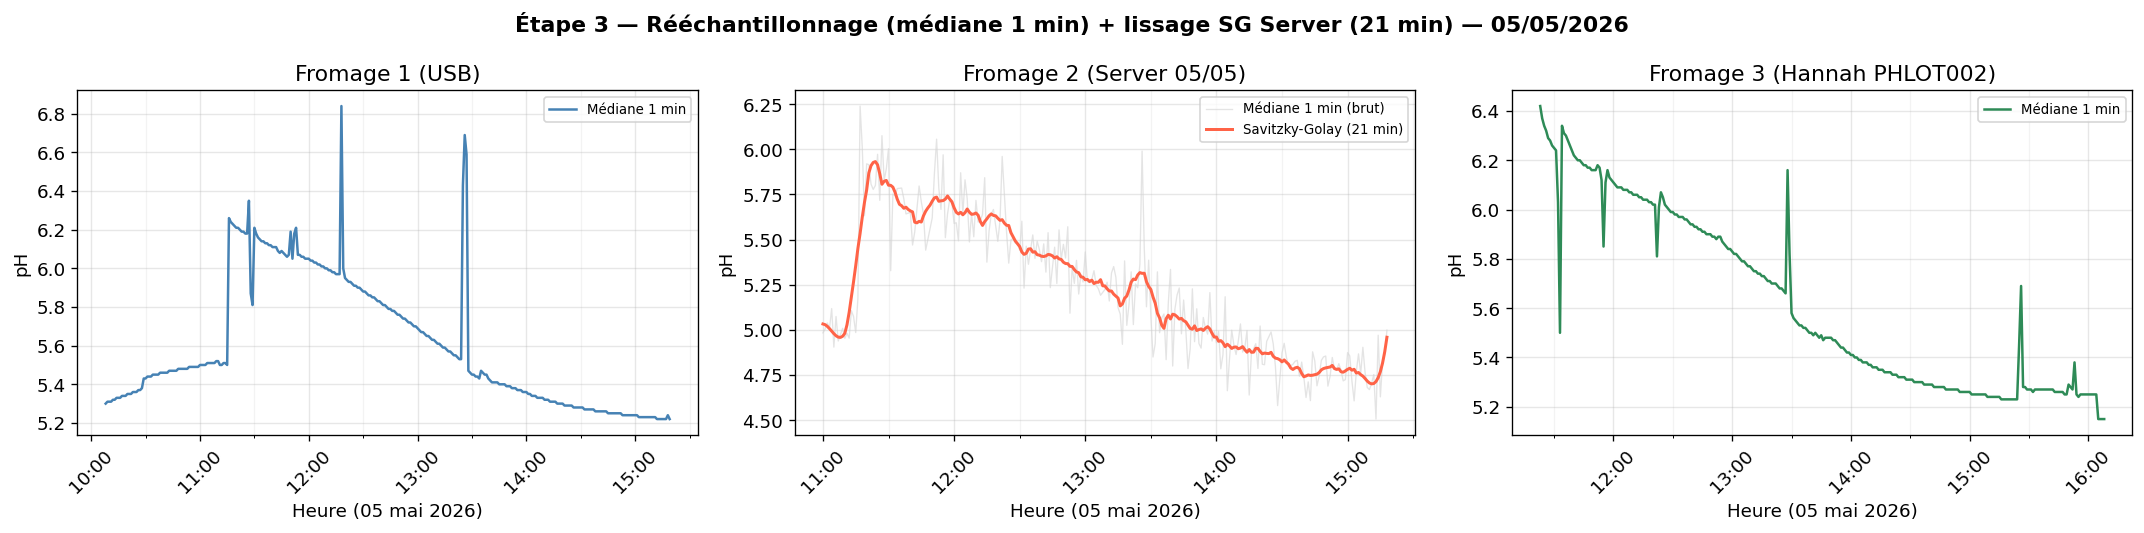

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(18, 4.5))

datasets = [
    (df1_res, None,       'Fromage 1 (USB)',              'steelblue'),
    (df2_res, df2_smooth, 'Fromage 2 (Server 05/05)',      'tomato'),
    (df3_res, None,       'Fromage 3 (Hannah PHLOT002)',   'seagreen'),
]

for ax, (res, smoothed, label, color) in zip(axes, datasets):
    if smoothed is not None:
        ax.plot(res.index, res.values, color='lightgrey', linewidth=0.8, alpha=0.6,
                label='Médiane 1 min (brut)')
        ax.plot(smoothed.index, smoothed.values, color=color, linewidth=1.8,
                label=f'Savitzky-Golay ({SG_WINDOW} min)')
    else:
        ax.plot(res.index, res.values, color=color, linewidth=1.5, label='Médiane 1 min')
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))
    ax.xaxis.set_major_locator(mdates.HourLocator(interval=1))
    ax.xaxis.set_minor_locator(mdates.MinuteLocator(byminute=[30]))
    ax.grid(True, which='minor', alpha=0.15)
    plt.setp(ax.xaxis.get_majorticklabels(), rotation=45)
    ax.set_title(label)
    ax.set_ylabel('pH')
    ax.set_xlabel('Heure (05 mai 2026)')
    ax.legend(fontsize=8)

plt.suptitle(f'Étape 3 — Rééchantillonnage (médiane 1 min) + lissage SG Server ({SG_WINDOW} min) — 05/05/2026',
             fontweight='bold')
plt.tight_layout()
plt.savefig(f'{FIGURES_DIR}/03_resampling.png', bbox_inches='tight')
plt.show()

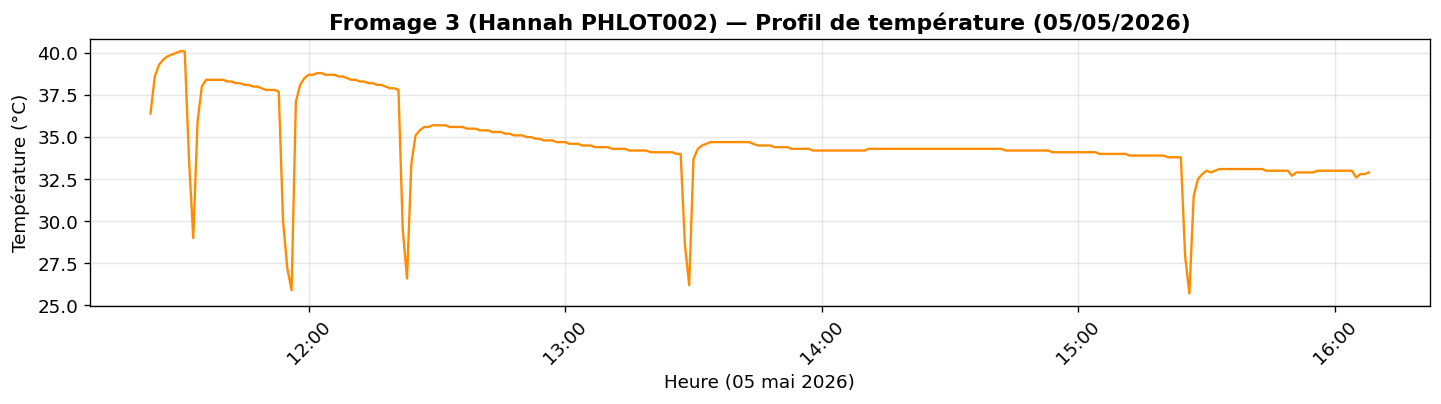

In [10]:
# Profil de température — Fromage 3 (Hannah PHLOT002)
fig, ax = plt.subplots(figsize=(12, 3.5))
ax.plot(df3_temp_res.index, df3_temp_res.values, color='darkorange', linewidth=1.4)
ax.xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))
ax.xaxis.set_major_locator(mdates.HourLocator(interval=1))
plt.setp(ax.xaxis.get_majorticklabels(), rotation=45)
ax.set_title('Fromage 3 (Hannah PHLOT002) — Profil de température (05/05/2026)', fontweight='bold')
ax.set_ylabel('Température (°C)')
ax.set_xlabel('Heure (05 mai 2026)')
plt.tight_layout()
plt.savefig(f'{FIGURES_DIR}/03b_temperature.png', bbox_inches='tight')
plt.show()

---
## 4. Correction de Nernst — Correction du pH par la Température

Une électrode pH suit l'**équation de Nernst** :

$$E = E_0 - \frac{RT\ln 10}{F}\cdot\mathrm{pH}$$

La pente $S(T) = -\frac{RT\ln 10}{F}$ dépend de la température (-59,16 mV/pH à 25 °C, -61,54 mV/pH à 37 °C).  
Lorsque la calibration se fait à $T_{\text{cal}}$ mais la mesure à $T_{\text{mes}}$,
le pH affiché est décalé. La valeur corrigée est :

$$\mathrm{pH}_{\text{corr}} =
  \mathrm{pH}_{\text{iso}} +
  (\mathrm{pH}_{\text{mes}} - \mathrm{pH}_{\text{iso}})
  \cdot \frac{T_{\text{mes}}}{T_{\text{cal}}}$$

où $T$ est en **Kelvin** et $\mathrm{pH}_{\text{iso}} \approx 7{,}0$ (point isoélectrique).

| Source | T disponible ? | mV disponible ? | Correction |
|--------|----------------|-----------------|------------|
| Fromage 1 (USB proxy)  | ✗ supposée 35 °C | ✓ | Rapport de pente |
| Fromage 2 (Server)     | ✗ supposée 35 °C | ✗ | Rapport de pente |
| Fromage 3 (Hannah)     | ✓ mesurée        | ✓ | Correction complète |

In [11]:
PH_ISO  = 7.0

def nernst_correct(pH_meas, T_meas_C, T_cal_C=T_CAL, pH_iso=PH_ISO):
    T_meas_K = T_meas_C + 273.15
    T_cal_K  = T_cal_C  + 273.15
    return pH_iso + (pH_meas - pH_iso) * (T_meas_K / T_cal_K)

# ── Fromage 1 : température supposée 35 °C (pas de capteur T sur USB) ─────────
T_F1_ASSUMED = 35.0
pH1_corr = nernst_correct(df1_smooth, T_meas_C=T_F1_ASSUMED)

# ── Fromage 2 : température supposée 35 °C ────────────────────────────────────
T_F2_ASSUMED = 35.0
pH2_corr = nernst_correct(df2_smooth, T_meas_C=T_F2_ASSUMED)

# ── Fromage 3 (Hannah PHLOT002) : pas de correction Nernst ───────────────────
# La sonde Hanna effectue déjà une compensation ATC interne via son capteur
# de température intégré. Appliquer Nernst introduirait une double compensation.
idx3     = df3_smooth.index.intersection(df3_temp_res.index)
pH3_meas = df3_smooth.loc[idx3]
temp3    = df3_temp_res.loc[idx3]
pH3_corr = pH3_meas.copy()   # ATC interne — pas de correction supplémentaire

print("Correction Nernst appliquée à F1 et F2 (T supposée 35°C)")
print("F3 (Hannah PHLOT002) : ATC interne — valeur brute utilisée directement")
print(f"Δ pH moyen F1 : {(pH1_corr - df1_smooth).mean():.4f}")
print(f"Δ pH moyen F2 : {(pH2_corr - df2_smooth).mean():.4f}")


Correction Nernst appliquée à F1 et F2 (T supposée 35°C)
F3 (Hannah PHLOT002) : ATC interne — valeur brute utilisée directement
Δ pH moyen F1 : -0.0469
Δ pH moyen F2 : -0.0597


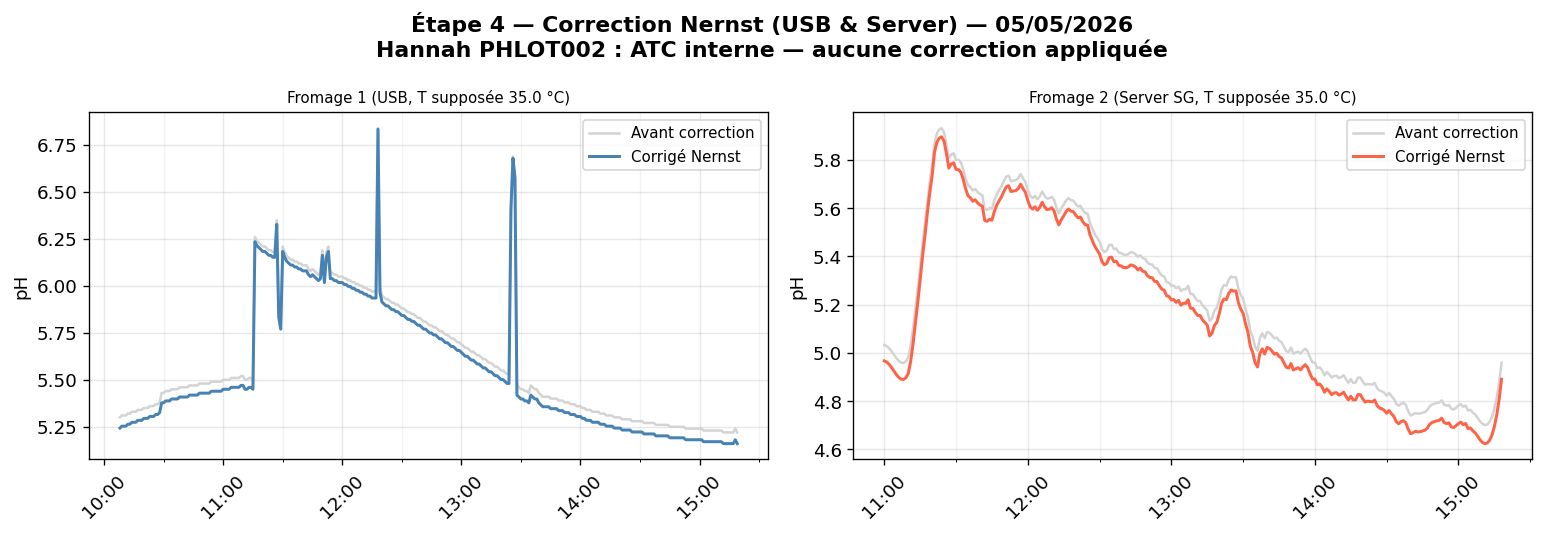

In [12]:
# ── Avant / après correction pour USB et Server uniquement ──────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

# Server déjà lissé par SG — pas de rolling supplémentaire
spec = [
    (df1_smooth, pH1_corr, f'Fromage 1 (USB, T supposée {T_F1_ASSUMED} °C)', 'steelblue'),
    (df2_smooth, pH2_corr, f'Fromage 2 (Server SG, T supposée {T_F2_ASSUMED} °C)', 'tomato'),
]

for ax, (measured, corrected, label, color) in zip(axes, spec):
    ax.plot(measured.index,  measured.values,  color='lightgrey', linewidth=1.5,
            label='Avant correction')
    ax.plot(corrected.index, corrected.values, color=color, linewidth=1.8,
            label='Corrigé Nernst')
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))
    ax.xaxis.set_major_locator(mdates.HourLocator(interval=1))
    ax.xaxis.set_minor_locator(mdates.MinuteLocator(byminute=[30]))
    ax.grid(True, which='minor', alpha=0.15)
    plt.setp(ax.xaxis.get_majorticklabels(), rotation=45)
    ax.set_title(label, fontsize=9)
    ax.set_ylabel('pH')
    ax.legend(fontsize=9)

plt.suptitle(
    'Étape 4 — Correction Nernst (USB & Server) — 05/05/2026\n'
    'Hannah PHLOT002 : ATC interne — aucune correction appliquée',
    fontweight='bold'
)
plt.tight_layout()
plt.savefig(f'{FIGURES_DIR}/04_nernst_correction.png', bbox_inches='tight')
plt.show()

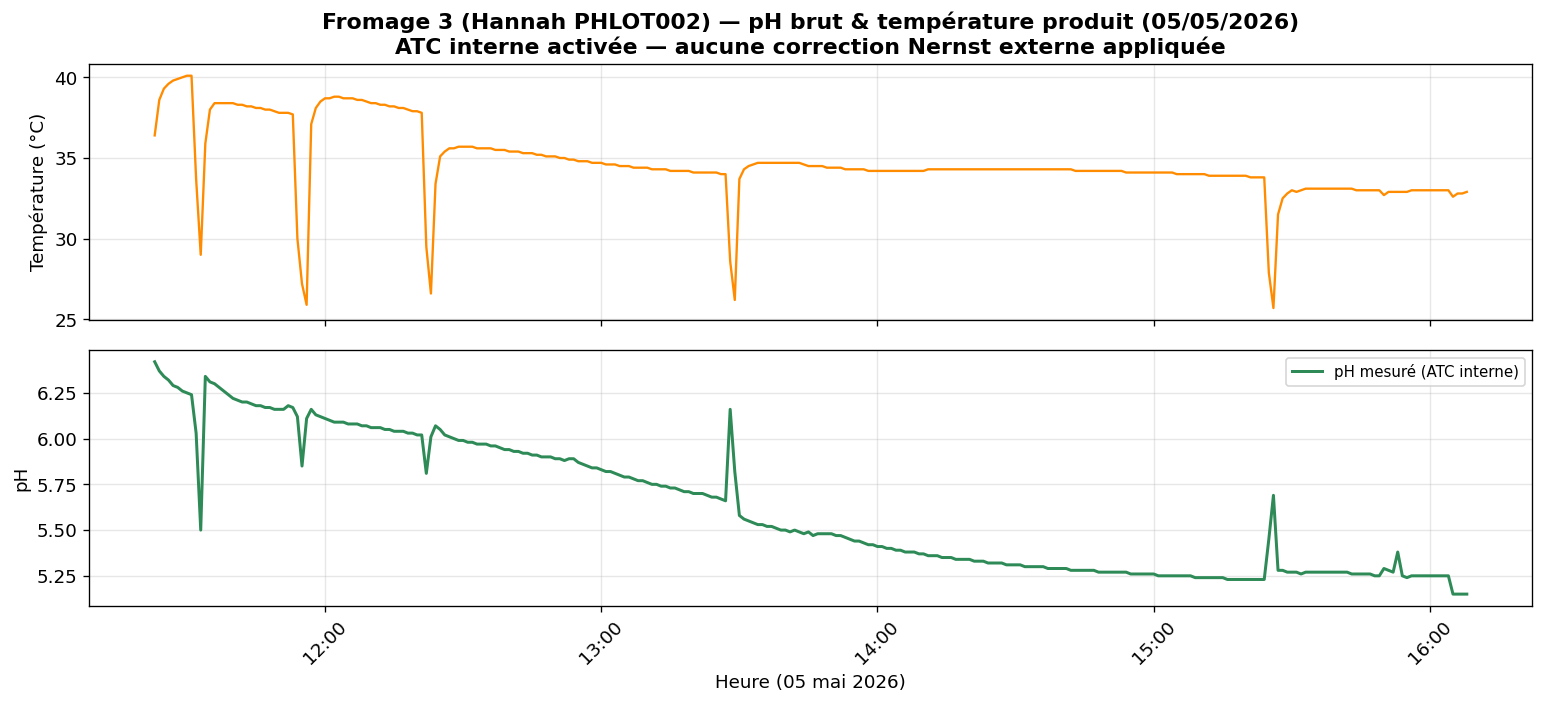

In [13]:
# ── Fromage 3 (Hannah) : pH brut + température — pas de correction Nernst ───
fig, axes = plt.subplots(2, 1, figsize=(13, 6), sharex=True)

axes[0].plot(temp3.index, temp3.values, color='darkorange', linewidth=1.4)
axes[0].set_ylabel('Température (°C)')
axes[0].set_title(
    'Fromage 3 (Hannah PHLOT002) — pH brut & température produit (05/05/2026)\n'
    'ATC interne activée — aucune correction Nernst externe appliquée',
    fontweight='bold'
)

axes[1].plot(pH3_meas.index, pH3_meas.values, color='seagreen', linewidth=1.8,
             label='pH mesuré (ATC interne)')
axes[1].set_ylabel('pH')
axes[1].set_xlabel('Heure (05 mai 2026)')
axes[1].legend(fontsize=9)
axes[1].xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))
axes[1].xaxis.set_major_locator(mdates.HourLocator(interval=1))
plt.setp(axes[1].xaxis.get_majorticklabels(), rotation=45)

plt.tight_layout()
plt.savefig(f'{FIGURES_DIR}/04b_hannah_atc.png', bbox_inches='tight')
plt.show()


---
## 5. Comparaison Finale — Profils Corrigés & Fit Logistique

> **Session 05/05** : trois capteurs réels disponibles. L'USB démarre à 10:08 (Fromage 1), le Server à 11:00 (Fromage 2), Hannah à 11:23 (Fromage 3). La fenêtre de fit commune est fixée à la période de chevauchement actif des trois signaux.

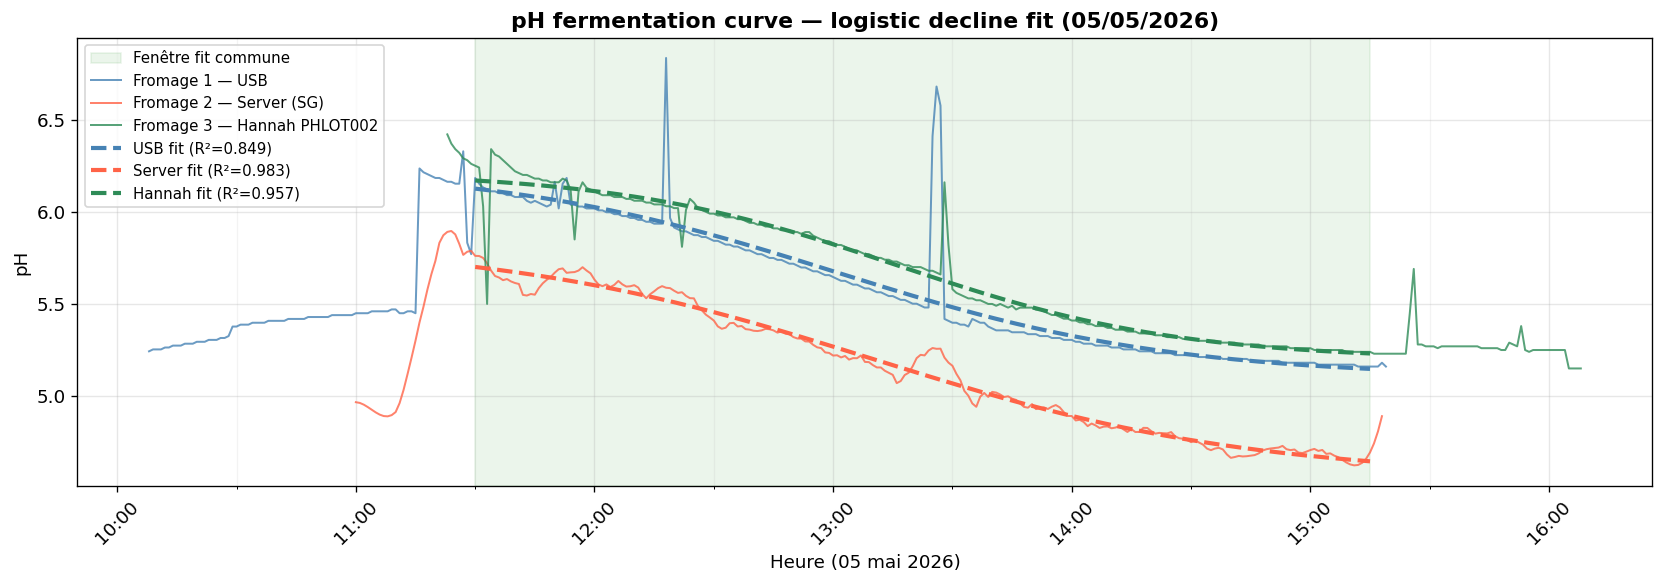

In [14]:
def logistic_decline(t, L, pH0, k, t0):
    """pH(t) = L + (pH0 - L) / (1 + exp(k*(t - t0)))"""
    return L + (pH0 - L) / (1 + np.exp(k * (t - t0)))

def fit_logistic(series, fit_start, fit_end):
    t_abs = series.index
    t     = (t_abs - t_abs[0]).total_seconds() / 3600
    y     = series.values
    mask  = (t_abs >= fit_start) & (t_abs <= fit_end)
    t_fit, y_fit = t[mask], y[mask]
    if len(t_fit) < 4:
        return None, None, None
    p0 = [y.min(), y.max(), 2.0, np.median(t_fit)]
    try:
        popt, _ = curve_fit(logistic_decline, t_fit, y_fit, p0=p0, maxfev=10000)
        y_pred_fit = logistic_decline(t_fit, *popt)
        ss_res = np.sum((y_fit - y_pred_fit) ** 2)
        ss_tot = np.sum((y_fit - y_fit.mean()) ** 2)
        r2 = 1 - ss_res / ss_tot
        return t_abs[mask], y_pred_fit, r2
    except Exception as e:
        print(f'Fit échoué : {e}')
        return None, None, None

# Server déjà lissé par SG — pas de rolling supplémentaire
pH2_corr_vis = pH2_corr.dropna()

FW_START    = pd.Timestamp('2026-05-05 11:30')
FW_END      = pd.Timestamp('2026-05-05 15:15')

idx1, fit1, r2_1 = fit_logistic(pH1_corr,     FW_START, FW_END)
idx2, fit2, r2_2 = fit_logistic(pH2_corr_vis, FW_START, FW_END)
idx3, fit3, r2_3 = fit_logistic(pH3_corr,     FW_START, FW_END)

fig, ax = plt.subplots(figsize=(14, 5))

ax.axvspan(FW_START, FW_END, alpha=0.08, color='green', label='Fenêtre fit commune')

ax.plot(pH1_corr.index,     pH1_corr.values,     color='steelblue', linewidth=1.2, alpha=0.8,
        label='Fromage 1 — USB')
ax.plot(pH2_corr_vis.index, pH2_corr_vis.values, color='tomato',    linewidth=1.2, alpha=0.8,
        label='Fromage 2 — Server (SG)')
ax.plot(pH3_corr.index,     pH3_corr.values,     color='seagreen',  linewidth=1.2, alpha=0.8,
        label='Fromage 3 — Hannah PHLOT002')

if fit1 is not None:
    ax.plot(idx1, fit1, color='steelblue', linewidth=2.5, linestyle='--',
            label=f'USB fit (R²={r2_1:.3f})')
if fit2 is not None:
    ax.plot(idx2, fit2, color='tomato',    linewidth=2.5, linestyle='--',
            label=f'Server fit (R²={r2_2:.3f})')
if fit3 is not None:
    ax.plot(idx3, fit3, color='seagreen',  linewidth=2.5, linestyle='--',
            label=f'Hannah fit (R²={r2_3:.3f})')

ax.xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))
ax.xaxis.set_major_locator(mdates.HourLocator(interval=1))
ax.xaxis.set_minor_locator(mdates.MinuteLocator(byminute=[30]))
ax.grid(True, which='minor', alpha=0.15)
plt.setp(ax.xaxis.get_majorticklabels(), rotation=45)
ax.set_xlabel('Heure (05 mai 2026)')
ax.set_ylabel('pH')
ax.set_title('pH fermentation curve — logistic decline fit (05/05/2026)', fontweight='bold')
ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig(f'{FIGURES_DIR}/05_final_comparison.png', bbox_inches='tight')
plt.show()

In [15]:
# ── Table des jalons clés ──────────────────────────────────────────────────────
def first_crossing(series, threshold):
    below = series[series <= threshold]
    return below.index[0] if not below.empty else None

thresholds = [5.8, 5.5, 5.3, 5.2]
rows = []
for thr in thresholds:
    t1 = first_crossing(pH1_corr, thr)
    t2 = first_crossing(pH2_corr, thr)
    t3 = first_crossing(pH3_corr, thr)
    rows.append({
        'Seuil pH': thr,
        'Fromage 1 (proxy)': t1.strftime('%H:%M') if t1 else '—',
        'Fromage 2 (Server)': t2.strftime('%H:%M') if t2 else '—',
        'Fromage 3 (Hannah)': t3.strftime('%H:%M') if t3 else '—',
    })

df_milestones = pd.DataFrame(rows).set_index('Seuil pH')
print('Jalons d\'acidification (heure de franchissement) — 05/05/2026')
df_milestones

Jalons d'acidification (heure de franchissement) — 05/05/2026


,Fromage 1 (proxy),Fromage 2 (Server),Fromage 3 (Hannah)
Seuil pH,,,
5.8,10:08,11:00,11:33
5.5,10:08,11:00,11:33
5.3,10:08,11:00,14:32
5.2,14:45,11:00,16:05


---
## 6. Modèle de Luedeking-Piret (système ODE)

Le modèle est implémenté comme un **système d'EDO** (suggestion Prof. Bocquel) :

$$\frac{dX}{dt} = \mu \cdot X \cdot (1 - X)$$

$$\frac{dA}{dt} = \alpha \frac{dX}{dt} + \beta X$$

- **X(t)** = biomasse bactérienne normalisée [0, 1]
- **A(t)** = proxy acide lactique = pH₀ − pH(t)
- **μ** = taux de croissance spécifique
- **α** = coefficient lié à la croissance active
- **β** = coefficient indépendant de la croissance

Paramètres identifiés par `scipy.optimize.minimize` (Nelder-Mead) + `solve_ivp` (RK45).


In [16]:
from scipy.integrate import solve_ivp
from scipy.optimize import minimize

def lp_ode(t, y, mu, alpha, beta):
    X, A = y
    dXdt = mu * X * (1 - X)
    dAdt = alpha * dXdt + beta * X
    return [dXdt, dAdt]

def fit_lp_ode(ph_series, fit_start, fit_end):
    ph = ph_series[(ph_series.index >= fit_start) & (ph_series.index <= fit_end)].dropna()
    # Rolling median to suppress residual spikes before computing A(t)
    ph = ph.rolling(window=5, center=True, min_periods=1).median()
    t     = (ph.index - ph.index[0]).total_seconds() / 3600
    A_obs = ph.values[0] - ph.values
    # Clip to non-negative: model assumes monotonic acid production
    A_obs = np.clip(A_obs, 0, None)
    X0, A0 = 0.01, 0.0

    def residuals(params):
        mu, alpha, beta = params
        if mu <= 0 or alpha < 0 or beta < 0:
            return 1e10
        sol = solve_ivp(
            lp_ode, [t[0], t[-1]], [X0, A0],
            args=(mu, alpha, beta),
            t_eval=t, method='RK45', rtol=1e-6, atol=1e-8
        )
        if not sol.success or sol.y.shape[1] != len(t):
            return 1e10
        return np.sum((sol.y[1] - A_obs) ** 2)

    res = minimize(residuals, x0=[2.0, 0.5, 0.05], method='Nelder-Mead',
                   options={'xatol': 1e-6, 'fatol': 1e-8, 'maxiter': 8000})
    mu_f, alpha_f, beta_f = res.x

    sol = solve_ivp(
        lp_ode, [t[0], t[-1]], [X0, A0],
        args=(mu_f, alpha_f, beta_f),
        t_eval=t, method='RK45', rtol=1e-6, atol=1e-8
    )
    A_sim = sol.y[1]; X_sim = sol.y[0]
    ss_res = np.sum((A_sim - A_obs) ** 2)
    ss_tot = np.sum((A_obs - A_obs.mean()) ** 2)
    r2     = 1 - ss_res / ss_tot if ss_tot > 0 else 0.0
    return dict(t=t, A_obs=A_obs, A_sim=A_sim, X_sim=X_sim,
                mu=mu_f, alpha=alpha_f, beta=beta_f, r2=r2)

# All three probes use the same common window (start after moulage)
series_lp = [
    ('Fromage 1 (USB)',    pH1_corr,     'steelblue', FW_START, FW_END),
    ('Fromage 2 (Server)', pH2_corr_vis, 'tomato',    FW_START, FW_END),
    ('Fromage 3 (Hannah)', pH3_corr,     'seagreen',  FW_START, FW_END),
]

results_lp = {}
for name, ph_series, color, fw_s, fw_e in series_lp:
    try:
        res = fit_lp_ode(ph_series, fw_s, fw_e)
        res['color'] = color
        results_lp[name] = res
        print(f"{name}: μ={res['mu']:.3f}  α={res['alpha']:.4f}  β={res['beta']:.4f}  R²={res['r2']:.3f}")
    except Exception as e:
        print(f'{name} : erreur — {e}')

rows_lp = []
for name, res in results_lp.items():
    ratio = round(res['alpha'] / res['beta'], 2) if abs(res['beta']) > 1e-6 else '∞'
    dom   = 'croissance' if res['alpha'] > res['beta'] else 'stationnaire'
    rows_lp.append({
        'Fromage':               name,
        'μ (taux croissance)':    round(res['mu'],    4),
        'α (growth-assoc.)':      round(res['alpha'], 4),
        'β (non-growth-assoc.)':  round(res['beta'],  4),
        'α/β':                    ratio,
        'Dominance':              dom,
        'R²':                     round(res['r2'],    3),
    })
pd.DataFrame(rows_lp).set_index('Fromage')


Fromage 1 (USB): μ=5.765  α=0.3709  β=0.2443  R²=0.924
Fromage 2 (Server): μ=6.215  α=0.3086  β=0.2956  R²=0.970
Fromage 3 (Hannah): μ=25.259  α=0.0363  β=0.3076  R²=0.976


,μ (taux croissance),α (growth-assoc.),β (non-growth-assoc.),α/β,Dominance,R²
Fromage,,,,,,
Fromage 1 (USB),5.7655,0.3709,0.2443,1.52,croissance,0.924
Fromage 2 (Server),6.2154,0.3086,0.2956,1.04,croissance,0.970
Fromage 3 (Hannah),25.2586,0.0363,0.3076,0.12,stationnaire,0.976


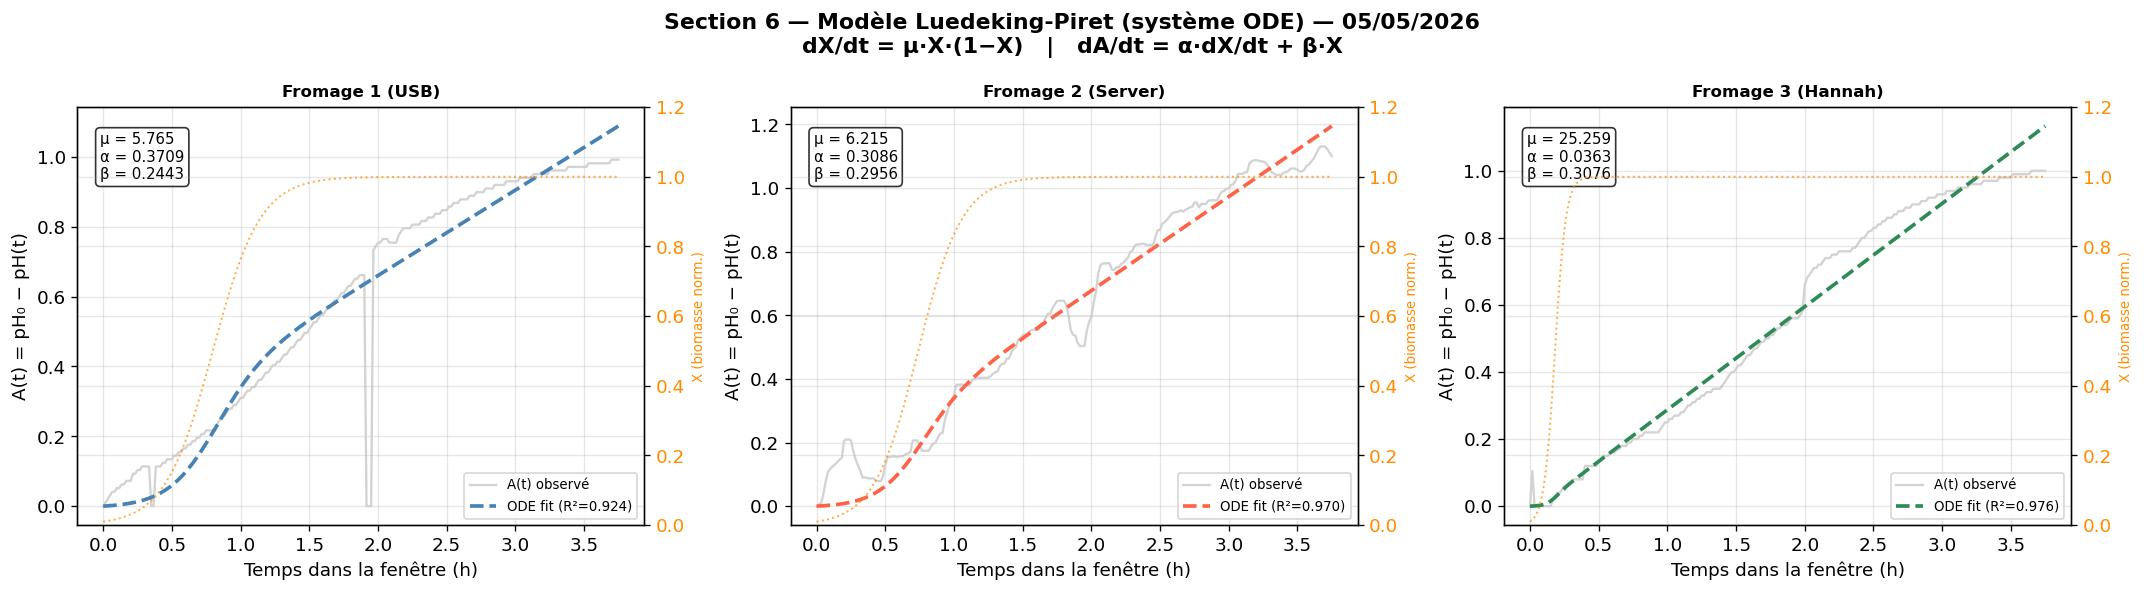

In [17]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, (name, res) in zip(axes, results_lp.items()):
    color = res['color']

    ax.plot(res['t'], res['A_obs'], color='lightgrey', linewidth=1.4,
            label='A(t) observé')
    ax.plot(res['t'], res['A_sim'], color=color, linewidth=2.2,
            linestyle='--', label=f'ODE fit (R²={res["r2"]:.3f})')

    ax2 = ax.twinx()
    ax2.plot(res['t'], res['X_sim'], color='darkorange', linewidth=1.2,
             linestyle=':', alpha=0.7, label='X(t) simulé')
    ax2.set_ylabel('X (biomasse norm.)', color='darkorange', fontsize=8)
    ax2.tick_params(axis='y', labelcolor='darkorange')
    ax2.set_ylim(0, 1.2)

    ax.text(0.04, 0.94,
            f'μ = {res["mu"]:.3f}\nα = {res["alpha"]:.4f}\nβ = {res["beta"]:.4f}',
            transform=ax.transAxes, fontsize=9, verticalalignment='top',
            bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

    ax.set_title(name, fontsize=10, fontweight='bold')
    ax.set_xlabel('Temps dans la fenêtre (h)')
    ax.set_ylabel('A(t) = pH₀ − pH(t)')
    ax.legend(fontsize=8, loc='lower right')

plt.suptitle(
    'Section 6 — Modèle Luedeking-Piret (système ODE) — 05/05/2026\n'
    'dX/dt = μ·X·(1−X)   |   dA/dt = α·dX/dt + β·X',
    fontweight='bold'
)
plt.tight_layout()
plt.savefig(f'{FIGURES_DIR}/06_luedeking_piret_ode.png', bbox_inches='tight')
plt.show()


---
## 7. Notes & Prochaines Étapes

- [ ] Confirmer la température de calibration réelle de l'USB (supposée 25 °C → 35 °C à vérifier)
- [ ] Confirmer si PHLOT002 a été arrêté avant la fin réelle de la fermentation (pH final 5,15)
- [ ] Ajouter les scores sensoriels / texturaux dès qu'ils seront disponibles
- [ ] Corréler les paramètres du fit logistique (L, k, t0) avec le rendement frais
- [ ] Comparer les paramètres Luedeking-Piret avec la session du 28/04

| Session | Rendement frais | Capteurs actifs | pH final USB |
|---------|-----------------|-----------------|---------------|
| 28/04   | 12,17 %         | USB + Server + PHLOT001 | ~4.0 (sonde sortie) |
| 05/05   | 11,80 %         | USB + Server + PHLOT002 | 5,22 (à 15:20) |